<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-failure-prediction/blob/main/Data%20Preparation%20ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSc Project - Data Preparation for ML

This notebook contains code for and MSc Project about predicting time-to-failure of water mains in Scotland. In particular, the code contains data preparation for machine learning models - cleaning and manipulation.

## Import Data

In this section, data is imported from my Google Drive. Data is available on assets, failures/bursts, soil, pressure, water quality and climate.

In [ ]:
# mount Google Drive

from google.colab import drive

drive.mount("/content/drive", force_remount = True)

Mounted at /content/drive


In [ ]:
# import data

import pandas as pd

assets = pd.read_csv("/content/drive/MyDrive/MSc project/SW data/Assets.csv", encoding = "latin1")
bursts = pd.read_csv("/content/drive/MyDrive/MSc project/SW data/burst_data.csv", encoding = "latin1")
soil = pd.read_csv("/content/drive/MyDrive/MSc project/SW data/soil-pipe-matched.csv", encoding="utf-8-sig")
samples_15_21 = pd.read_csv("/content/drive/MyDrive/MSc project/SW data/samples 15-21.csv", encoding = "latin1")
samples_22_26 = pd.read_csv("/content/drive/MyDrive/MSc project/SW data/samples 22-26.csv", encoding = "latin1")

import xarray as xr

frost_geo = xr.open_dataset("/content/drive/MyDrive/MSc project/SW data/frosts_annual.nc")
frost = frost_geo.to_dataframe() # geographical data converted to a pandas dataframe

/tmp/ipykernel_662/3474638998.py:5: DtypeWarning: Columns (22,23,28) have mixed types. Specify dtype option on import or set low_memory=False.
  assets = pd.read_csv("/content/drive/MyDrive/MSc project/SW data/Assets.csv", encoding = "latin1")
/tmp/ipykernel_662/3474638998.py:7: DtypeWarning: Columns (85,86,87,92,94,95,96,97,98,99,104,106,107,108) have mixed types. Specify dtype option on import or set low_memory=False.
  soil = pd.read_csv("/content/drive/MyDrive/MSc project/SW data/soil-pipe-matched.csv", encoding="utf-8-sig")
/tmp/ipykernel_662/3474638998.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  samples_15_21 = pd.read_csv("/content/drive/MyDrive/MSc project/SW data/samples 15-21.csv", encoding = "latin1")
/tmp/ipykernel_662/3474638998.py:9: DtypeWarning: Columns (0,11,12,13,14,15,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  samples_22_26 = pd.read_csv("/content/drive/MyDrive/

# Data Cleaning

In this section data containing information abouts assets, bursts and soil is cleaned, details follow below.

### Assets

It is desired to remove assets that are not of interest to the water networks maintenance planning team and duplicated assets.

In [ ]:
# removing assets that are not of interest to the team

assets_cleaned = assets[assets["Type"] == "Distribution"] # only keeping distribution mains

assets_cleaned = assets_cleaned[assets_cleaned["Operational.Status"] != "Abandoned"] # remove abondened assets

assets_cleaned = assets_cleaned[assets_cleaned["Operational.Status"] != "Removed"] # remove removed assets

assets_cleaned = assets_cleaned.drop_duplicates(subset = ["Asset.ID"]) # remove duplicates


Some of the assets have missing values for diamater, age, material or surface. It is examined how severe the issue is by looking at the % of the total length of assets.

In [ ]:
# examine % of total length of assets that has missing diamater, age, material or surface code

print(assets_cleaned[pd.isnull(assets_cleaned['ARM_DIAMETER'])]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

print(assets_cleaned[pd.isnull(assets_cleaned['ARM_AGE'])]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

print(assets_cleaned[assets_cleaned['ARM_MATERIAL'] == "MISSING"]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

print(assets_cleaned[assets_cleaned['ARM_SURFACE_CODE'] == "MISSING"]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

0.9927640054107845
5.360436576563711
0.9144144065027073
11.214191390520968


Some missing values for the material could be imputed based on the information about the age of the asset. The age profile of assets by material is plotted and examined for this purpose.

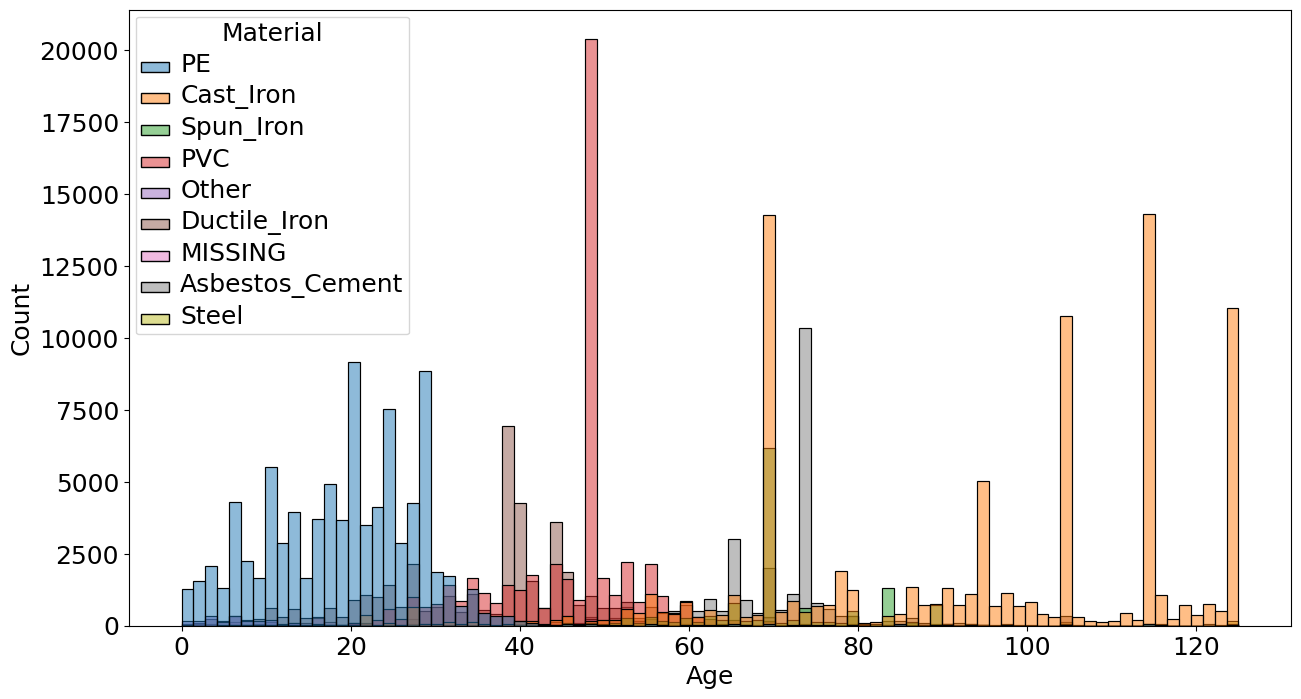

In [ ]:
# plot age profile of assets by material

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = [15, 8])

plot = sns.histplot(data = assets_cleaned,
             x = "ARM_AGE",
             hue = "ARM_MATERIAL")

plot.set_xlabel("Age", fontsize = 18)
plot.set_ylabel("Count", fontsize = 18)

legend = plot.get_legend()
legend.set_title("Material", prop={'size': 18})
plt.setp(legend.get_texts(), fontsize=18)


plot.tick_params(axis='both', labelsize=18)

plt.show()



# comment: if an asset it 8 years or younger, then it can be assumed it is made of PE - use for subsitituing material

Records containing missing values for diamater are removed, since they only make up less than 1% of the total length of all assets.

Records containing missing values for age are also removed, since they only make 5% of the total length. It is impossible to impute the data based on some other characteristics.

Records that had missing material and were younger than 8 years old, were imputer with PE as material. The remaining records with misising material are removed.

Assets with missing surface are removed from the data. It is impossible to impute this information using other characteristics.



In [ ]:
# missing values removal

assets_cleaned = assets_cleaned[pd.notnull(assets_cleaned["ARM_DIAMETER"])] # deletes records with missing diameter

assets_cleaned = assets_cleaned[pd.notnull(assets_cleaned["ARM_AGE"])] # deletes records with missing age

assets_cleaned.loc[(assets_cleaned["ARM_MATERIAL"] == "MISSING") & (assets_cleaned["ARM_AGE"] <= 8.0), "ARM_MATERIAL"] = "PE" # imputes assets that have missing material and are 8 or less years with PE

assets_cleaned = assets_cleaned[(assets_cleaned["ARM_MATERIAL"] != "MISSING")] # removes remaining assets with missing material

assets_cleaned = assets_cleaned[assets_cleaned["ARM_SURFACE_CODE"] != "Unknown"] # remove assets with unknown surface code (only 6 has unknown surface)

assets_cleaned = assets_cleaned[assets_cleaned["ARM_SURFACE_CODE"] != "MISSING"] # remove assets with missing surface code (~52k has missing surface)



Data is filtered to only contain columns of interest for further analysis. The selected columns are renamed.

In [ ]:
# select columns and re-name columns

assets_cleaned = assets_cleaned[["Asset.ID",
                                 "ARM_MATERIAL",
                                 "ARM_DIAMETER",
                                 "ARM_LENGTH",
                                 "ARM_LINING",
                                 "ARM_SURFACE_CODE",
                                 "ARM_COMMISSIONED",
                                 "X.Coordinate",
                                 "Y.Coordinate",
                                 "DMA_REF"
                                 ]] # selecting attributes

assets_cleaned = assets_cleaned.rename(columns = {"ARM_MATERIAL":"Material",
                                                        "ARM_DIAMETER": "Diameter",
                                                        "ARM_LENGTH": "Length",
                                                        "ARM_LINING": "Lining",
                                                  "ARM_SURFACE_CODE": "Surface",
                                                  "ARM_COMMISSIONED": "Date_commissioned"}) # renaming columns


Additional changes to date type and misisng values removal.

In [ ]:
# change type

assets_cleaned['Asset.ID'] = assets_cleaned['Asset.ID'].astype(int) # changing asset type from float to integer

assets_cleaned['Date_commissioned'] = pd.to_datetime(assets_cleaned['Date_commissioned'], errors = "coerce", dayfirst=True)


Some assets don't have the commissioned date in the right format (most likely due to data entry error), and are therefore removed from the data set.

In [ ]:
# remove assets that don't have commissioned date in the right format

assets_cleaned = assets_cleaned[~(pd.isnull(assets_cleaned['Date_commissioned']))]

In [ ]:
# remove assets with missing coordinates

assets_cleaned = assets_cleaned[~(pd.isna(assets_cleaned['X.Coordinate']))]
assets_cleaned = assets_cleaned[~(pd.isna(assets_cleaned['Y.Coordinate']))]

In [ ]:
# remove assets with missing DMA

assets_cleaned = assets_cleaned[~(pd.isna(assets_cleaned['DMA_REF']))]

### Frost days

Data on the number of days with temperature below 0 degrees Celsius as measured at ground level is provided. The dataset is cleaned to contain relevant information only in the right format.

In [ ]:
# data cleaning

frost_cleaned = frost[frost['latitude'] > 54] # only include sampling stations in Scotland

frost_cleaned = frost_cleaned[['time_bnds', "latitude", "longitude", "groundfrost"]]

frost_cleaned = frost_cleaned[pd.notnull(frost_cleaned['groundfrost'])] # removing stations with missing measurements

frost_cleaned = frost_cleaned.reset_index()

### Bursts

Bursts data is filtered to only contain relevant columns. Bursts without asset ID are also removed. Data types of some columns is also changed.

In [ ]:
# bursts cleaning

bursts_cleaned = bursts[["Asset.ID", "Raised.Date"]] # only selecting relevant information

bursts_cleaned = bursts_cleaned[pd.notnull(bursts_cleaned['Asset.ID'])] # removing bursts without asset ID

bursts_cleaned['Asset.ID'] = bursts_cleaned['Asset.ID'].astype(int) # changing Asset ID from float to integer

bursts_cleaned["Raised.Date"] = pd.to_datetime(bursts_cleaned["Raised.Date"], dayfirst=True) # transforms burst date to date format

Bursts that occured at the same asset on the same day, or next day, are removed from the records. They are assumed to come from the same event, but work orders were raised multiple times, hence the burst was logged multiple times.

In [ ]:
# remove bursts that were reported on the same day for the same asset

bursts_cleaned = bursts_cleaned.drop_duplicates(subset = ["Asset.ID", "Raised.Date"]) # delete duplicate bursts (same day, same asset)

In [ ]:
# only keep bursts if they occured more than 1 day between each other

bursts_cleaned = bursts_cleaned.sort_values(["Asset.ID", "Raised.Date"]) # sort bursts by date for each asset (required for the loop)


kept_rows = [] # create an empty set to record temaining bursts

for asset_id, bursts in bursts_cleaned.groupby("Asset.ID"): # note: this is a special type of loop that loops through the created groups

    previous_date = None

    for _, row in bursts.iterrows():

        current_date = row["Raised.Date"]

        if previous_date is None:
            kept_rows.append(row)


        else:
            day_diff = (current_date - previous_date).days

            if day_diff > 1:
                kept_rows.append(row)
                previous_date = current_date

bursts_cleaned = pd.DataFrame(kept_rows)




### Soil

Soil data is filtered to only contain relevant columns, instances with missing soil information are removed from the dataset and columns are re-named.

In [ ]:
# soil cleaning

soil_cleaned = soil[["asset_id", "msg84_2", "pH_900mm"]] # selecting only relevant information

soil_cleaned = soil_cleaned[pd.notnull(soil_cleaned["msg84_2"])] # removing assets with missing soil

soil_cleaned.columns = ["Asset.ID", "Soil", "Soil_pH"] # rename columns

### Pressure

Two data sets are available that contain information on pressure. The first dataset contain information on asset ID and the corresponding nodes on the asset where pressure was measured. The second dataset contains information on nodes and the corresponding pressure measurements. Some initial cleaning is done on both datasets.

In [ ]:
# data cleaning of assets and pressure

pressure_assets['asset_id'] = pd.to_numeric(pressure_assets['asset_id'], errors = "coerce")

pressure_assets_cleaned = pressure_assets[pressure_assets['asset_id'].isin(assets_cleaned['Asset.ID'])] # filter for relevant assets only

pressure_assets_cleaned = pressure_assets_cleaned[["us_node_id", "ds_node_id", "asset_id"]] # keeping only relevant columns

In [ ]:
# data cleaning of nodes and pressure

pressure_nodes_cleaned = nodes_pressure[nodes_pressure['Node_Type'] == "Node"] # only pressure measured at node type = node is of interest

# below a list of upsteam and downstream nodes for each asset is created

ds_node_id = pressure_assets_cleaned['ds_node_id'].to_list()

us_node_id = pressure_assets_cleaned['us_node_id'].to_list()

ds_node_id.extend(us_node_id)

# the created list is used below to filter the pressure and nodes data to only contain relevant nodes

pressure_nodes_cleaned = pressure_nodes_cleaned[pressure_nodes_cleaned['node_id'].isin(ds_node_id)]

pressure_nodes_cleaned = pressure_nodes_cleaned[['node_id', "P_Max__m_"]] # only keeping relevant columns



### Samples

Samples form 2015-2021 and 2022-2026 need to be combined into one file. Following that, two data sets are created for water pH and chlorine content.

In [ ]:
# combine datasets

samples_cleaned = pd.concat([samples_15_21, samples_22_26])


# Data manipulation

In this section, data is manipulated to join assets, bursts, pressure, frost days, water quality and soil data together.

The joined data set is split up into training, validation and test dataset based on burst dates.

Transfromations are applied on the resultant dataset to create data sets in tidy data format with attributes suitable for modelling. The final dataset will have each asset ID as an instance and time-to-failure as response attribute.

The resultant data is split into training, validation and test data set.

### Joining

Data on assets needs is joined with data on soil and bursts.

In [ ]:
# merging assets, bursts and soil together

assets_bursts = pd.merge(assets_cleaned, bursts_cleaned, how = "left", on = "Asset.ID")

assets_bursts_soil = pd.merge(assets_bursts, soil_cleaned, how = "left", on = "Asset.ID")

assets_bursts_soil = assets_bursts_soil[pd.notnull(assets_bursts_soil['Soil'])] # removing assets without soil

censored_data = assets_bursts_soil[~pd.notnull(assets_bursts_soil["Raised.Date"])] # keeping assets without bursts as censored data

assets_bursts_soil = assets_bursts_soil[pd.notnull(assets_bursts_soil['Raised.Date'])] # removing assets without bursts

Any assets that have censored data (have not had a burst yet) are saved in a separate file to later evaluate how the model performs on censored data.

In [ ]:
# save censored data

censored_data = assets_bursts_soil[~pd.notnull(assets_bursts_soil["Raised.Date"])] # keeping assets without bursts as censored data

censored_data = censored_data.drop(columns = ["Raised.Date"]) # removed raised date, as won't be needed for further analysis

censored_data.to_csv("/content/drive/MyDrive/MSc project/censored_data.csv", encoding ='latin1', index=False)

To join assets with pressure readings, the highest pressure for upstream and downstream node for each asset needs to be identified.To this dataset on pressure measurements is converted to a dictionary used to look up values.

In [ ]:
# convert the nodes dataset to a dictionary

nodes_pressure_dict = dict(zip(pressure_nodes_cleaned["node_id"], pressure_nodes_cleaned['P_Max__m_']))


NameError: name 'pressure_nodes_cleaned' is not defined

In [ ]:
# create pressure attribute


us_pressure = []

for us_node in pressure_assets_cleaned['us_node_id']: # extract upstream pressure for each asset

  us_pressure.append(nodes_pressure_dict.get(us_node))


ds_pressure = []

for ds_node in pressure_assets_cleaned['ds_node_id']: # extract upstream pressure for each asset

  ds_pressure.append(nodes_pressure_dict.get(ds_node))




pressure_assets_cleaned['pressure'] = max(us_pressure, ds_pressure) # add a column with maximum of downstream and upstream pressure

pressure_assets_cleaned = pressure_assets_cleaned[["asset_id", "pressure"]] # selecting only relevant columns

pressure_assets_cleaned = pressure_assets_cleaned.groupby(pressure_assets_cleaned['asset_id']).max().reset_index() # finding the maximum pressure for each asset from all nodes

In [ ]:
# joing pressure with assets, bursts and soil

assets_bursts_soil_pressure = pd.merge(assets_bursts_soil, pressure_assets_cleaned,
                                       how = "left", left_on = "Asset.ID", right_on = "asset_id")

NameError: name 'pressure_assets_cleaned' is not defined

To join assets with the no. of frost days, the closest measuring station needs to be identified for each asset

In [ ]:
# x and y coordinates from asset data need to be converted to longitude and latitude for comparison

from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)

assets_bursts_soil["longitude"], assets_bursts_soil["latitude"] = transformer.transform(
    assets_bursts_soil["X.Coordinate"].values,
    assets_bursts_soil["Y.Coordinate"].values
)

In [ ]:
import math
import numpy as np

for asset in assets_bursts_soil['Asset.ID']:


  assets_filtered_asset_id = assets_bursts_soil[assets_bursts_soil["Asset.ID"] == asset]

  lon = assets_filtered_asset_id['longitude'].iloc[0]

  lat = assets_filtered_asset_id['latitude'].iloc[0]


  distances = np.sqrt(
        (frost_cleaned["latitude"] - lat)**2 +
        (frost_cleaned["longitude"] - lon)**2
    )



  index = distances.idxmin()

  assets_bursts_soil.loc[assets_bursts_soil['Asset.ID'] == asset, "Frost_days"] = frost_cleaned.loc[index, "groundfrost"]


assets_bursts_soil_frost = assets_bursts_soil

To join data with water quality samples, average values of water quality are identifies for each zone where assets are located.

In [ ]:
# pH dataset

samples_pH = samples_cleaned[samples_cleaned["Determinand Name"] == "Hydrogen Ion"]
samples_pH = samples_pH[["DMA Reference", "Sample Result Numeric"]]

In [ ]:
# chlorine dataset

samples_chlorine = samples_cleaned[samples_cleaned["Determinand Name"] == "Free chlorine"]
samples_chlorine = samples_chlorine[["DMA Reference", "Sample Result Numeric"]]

In [ ]:
# calculate average concentrations

samples_pH_mean = samples_pH.groupby("DMA Reference").mean().reset_index()

samples_chlorine_mean = samples_chlorine.groupby("DMA Reference").mean().reset_index()

samples_pH_mean = samples_pH_mean.rename(columns = {"Sample Result Numeric": "Hydrogen Ion"}) # rename columns
samples_chlorine_mean = samples_chlorine_mean.rename(columns = {"Sample Result Numeric": "Free chlorine"}) # rename columns

In [ ]:
# merge data

assets_bursts_soil_frost_samples = pd.merge(assets_bursts_soil_frost, samples_pH_mean, left_on = "DMA_REF", right_on = "DMA Reference", how = "left")

assets_bursts_soil_frost_samples = pd.merge(assets_bursts_soil_frost_samples, samples_chlorine_mean, left_on = "DMA_REF", right_on = "DMA Reference", how = "left")

Only columns of interest are selected for further transformations.

In [ ]:
# select columns of interest

assets_bursts_soil_pressure_frost_samples = assets_bursts_soil_frost_samples[["Asset.ID",
                                                                                      "Material",
                                                                                      "Diameter",
                                                                                      "Length",
                                                                                      "Lining",
                                                                                      "Surface",
                                                                                      "Raised.Date",
                                                                                      "Soil",
                                                                                      "Soil_pH",
                                                                                      "Frost_days",
                                                                                      "Hydrogen Ion",
                                                                                      "Free chlorine",
                                                                                      "Date_commissioned"]]

In [ ]:
assets_bursts_soil_frost_samples = assets_bursts_soil_frost_samples[pd.notna(assets_bursts_soil_frost_samples["Soil_pH"])]
assets_bursts_soil_frost_samples = assets_bursts_soil_frost_samples[pd.notna(assets_bursts_soil_frost_samples["Hydrogen Ion"])]
assets_bursts_soil_frost_samples = assets_bursts_soil_frost_samples[pd.notna(assets_bursts_soil_frost_samples["Free chlorine"])]

In [ ]:
# rename resultant data

data_cleaned_joined = assets_bursts_soil_pressure_frost_samples

In [ ]:
# save resultant data

data_cleaned_joined.to_csv("/content/drive/MyDrive/MSc project/data_cleaned_joined.csv", encoding ='latin1', index=False)

### Transformations

The dataset needs to be transformed into a tidy data format with attributes suitable for modelling.

The latest two failures for each asset need to be extracted to create an attributes with time-to-failure, which is the response attribute.

In [ ]:
data_cleaned_joined = pd.read_csv("/content/drive/MyDrive/MSc project/data_cleaned_joined.csv", encoding = "latin1")

In [ ]:
data_cleaned_joined['Raised.Date'] = pd.to_datetime(data_cleaned_joined["Raised.Date"], dayfirst=True)

/tmp/ipykernel_662/1499100474.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  data_cleaned_joined['Raised.Date'] = pd.to_datetime(data_cleaned_joined["Raised.Date"], dayfirst=True)


In [ ]:
# get index for latest two bursts for each asset

index = data_cleaned_joined.groupby("Asset.ID")["Raised.Date"].nlargest(2).reset_index(level = 0, drop = True).index

In [ ]:
# filter data to contain only latest two bursts

data_cleaned_joined_filtered = data_cleaned_joined.loc[index]

A column "Previous bursts" is added as attributes. This column corresponds to the number of previous failures.

In [ ]:
# Calculate previous fails for each asset

previous_bursts = data_cleaned_joined["Asset.ID"].value_counts() - 1

previous_bursts = previous_bursts.reset_index()


In [ ]:
# Add a new column

data_cleaned_joined_filtered = data_cleaned_joined_filtered.merge(previous_bursts, on = "Asset.ID", how = "left")
data_cleaned_joined_filtered = data_cleaned_joined_filtered.rename(columns={"count":"Previous bursts"}) # change column name

A "Time-to-break" column is added as a new attribute to the assets, bursts and soil data set. This column corresponds to the response attribute. Time-to-burst is calculated as time since the start of burst records or since the latest burst.

In [ ]:
# Change data type to date (necessary for calculating time difference)

data_cleaned_joined_filtered["Raised.Date"] = pd.to_datetime(data_cleaned_joined_filtered["Raised.Date"], dayfirst=True) # transofrms burst date to date format

data_cleaned_joined_filtered['Date_commissioned'] = pd.to_datetime(data_cleaned_joined_filtered["Date_commissioned"], errors = "coerce")

In [ ]:
# Create "Time-to-break" column

data_cleaned_joined_filtered = data_cleaned_joined_filtered.sort_values(by = ["Asset.ID", "Raised.Date"]) # sorting bursts by raised date for each asset

start_date = bursts_cleaned['Raised.Date'].min()

# no previous bursts

data_cleaned_joined_filtered.loc[data_cleaned_joined_filtered['Previous bursts'] == 0, "Time-to-failure"] = \
  data_cleaned_joined_filtered['Raised.Date'] - start_date

data_cleaned_joined_filtered.loc[(data_cleaned_joined_filtered['Previous bursts'] == 0) & (data_cleaned_joined_filtered['Date_commissioned'] > start_date), "Time-to-break"] = \
  data_cleaned_joined_filtered['Raised.Date'] - data_cleaned_joined_filtered['Date_commissioned']

# previous bursts

data_cleaned_joined_filtered.loc[data_cleaned_joined_filtered['Previous bursts'] > 0, "Time-to-failure"] = \
  data_cleaned_joined_filtered.groupby("Asset.ID")["Raised.Date"].diff(1)



In [ ]:
# Convert "Time-to-break" to days

data_cleaned_joined_filtered['Time-to-falure'] = data_cleaned_joined_filtered['Time-to-failure'].dt.days

In [ ]:
# Convert "Time-to-break" to years

data_cleaned_joined_filtered["Time-to-failure"] = data_cleaned_joined_filtered["Time-to-break"]/365

In [ ]:
# remove assets with bursts after date commissioned

data_cleaned_joined_filtered = data_cleaned_joined_filtered[data_cleaned_joined_filtered['Time-to-break'] > 0]

A column "Age" is added. For assets with only one burst, it equals to the age at the start of the burst records. For assets with at least two bursts, it equals to age at second last break, since time-to-failure since second last break break is predicted.

In [ ]:
# Add "Age" column

# age at start of burst records

data_cleaned_joined_filtered.loc[data_cleaned_joined_filtered["Previous bursts"] == 0, "Age"] = \
  (start_date - data_cleaned_joined_filtered['Date_commissioned']).dt.days

# age at data comissioned


data_cleaned_joined_filtered.loc[(data_cleaned_joined_filtered['Previous bursts'] == 0) & (data_cleaned_joined_filtered['Date_commissioned'] > start_date), "Age"] = \
  0


# age at last burst

data_cleaned_joined_filtered.loc[data_cleaned_joined_filtered["Previous bursts"] > 0, "Age"] = \
  (data_cleaned_joined_filtered['Raised.Date'].shift(1) - data_cleaned_joined_filtered['Date_commissioned']).dt.days


In [ ]:
# remove assets that had bursts before comissioned date - errors

data_cleaned_joined_filtered = data_cleaned_joined_filtered[data_cleaned_joined_filtered['Age'] >= 0]

Save the final data set as attributes.

In [ ]:
# only keep the latest burst for each asset

data_cleaned_joined_filtered = data_cleaned_joined_filtered[pd.notnull(data_cleaned_joined_filtered['Time-to-failure'])]  # only keeping last burst for each asset

In [ ]:
# remove missing values

data_cleaned_joined_filtered = data_cleaned_joined_filtered[pd.notna(data_cleaned_joined_filtered['Soil_pH'])]

data_cleaned_joined_filtered = data_cleaned_joined_filtered[pd.notna(data_cleaned_joined_filtered['Hydrogen Ion'])]

data_cleaned_joined_filtered = data_cleaned_joined_filtered[pd.notna(data_cleaned_joined_filtered["Free chlorine"])]

In [ ]:
# save final data as attributes

attributes = data_cleaned_joined_filtered


In [ ]:
attributes.to_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding ='latin1', index=False)

### Splitting

The final dataset is split into training, testing and validation datasets to use for modelling. The ratio is 75%-10%-15% for training, validation and test data sets.

In [ ]:
from sklearn.model_selection import train_test_split

X = attributes[["Material", "Diameter", "Length", "Lining", "Surface", "Soil", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine", "Previous bursts", "Age"]]
y = attributes['Time-to-failure']

X_train, X_draft, y_train, y_draft = train_test_split(X, y, test_size = 0.30, random_state = 42)

X_valid, X_test, y_valid, y_test = train_test_split(X_draft, y_draft, test_size = 0.67, random_state = 42)

In [ ]:
# save resultant data

X_train.to_csv("/content/drive/MyDrive/MSc project/X_train.csv", encoding ='latin1', index=False)
X_valid.to_csv("/content/drive/MyDrive/MSc project/X_valid.csv", encoding ='latin1', index=False)
X_test.to_csv("/content/drive/MyDrive/MSc project/X_test.csv", encoding ='latin1', index=False)


y_train.to_csv("/content/drive/MyDrive/MSc project/y_train.csv", encoding ='latin1', index=False)
y_valid.to_csv("/content/drive/MyDrive/MSc project/y_valid.csv", encoding ='latin1', index=False)
y_test.to_csv("/content/drive/MyDrive/MSc project/y_test.csv", encoding ='latin1', index=False)